
# Exploring subset of dataset by looking at 1000 rows

In [14]:
import pandas as pd
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/albsve2/De1project/main/data/sample_yellow_taxi_1000rows.parquet"
response = requests.get(url)
df = pd.read_parquet(BytesIO(response.content))
df.head(1000)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.00,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.00,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.00,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.00,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.00,1.0,16.10,2.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2,2024-01-01 00:24:35,2024-01-01 00:33:04,1.0,1.63,1.0,N,48,142,2,10.7,1.0,0.5,0.00,0.00,1.0,15.70,2.5,0.0
996,2,2024-01-01 00:42:40,2024-01-01 00:51:13,2.0,1.39,1.0,N,239,263,1,10.7,1.0,0.5,3.14,0.00,1.0,18.84,2.5,0.0
997,1,2024-01-01 00:10:40,2024-01-01 00:22:59,2.0,3.00,1.0,N,79,141,1,14.9,3.5,0.5,4.00,0.00,1.0,23.90,2.5,0.0
998,1,2024-01-01 00:28:44,2024-01-01 00:55:06,2.0,15.80,1.0,N,140,16,1,59.0,3.5,0.5,0.00,6.94,1.0,70.94,2.5,0.0


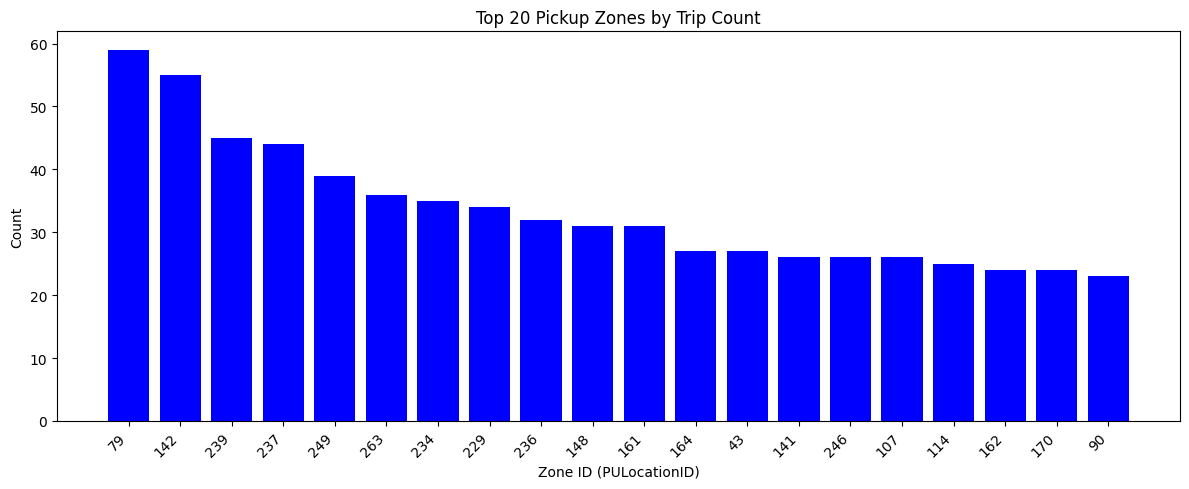

In [20]:
import matplotlib.pyplot as plt

zone_counts = (df["PULocationID"].value_counts().sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(zone_counts.index.astype(str), zone_counts.values, color="blue")
ax.set_xlabel("Zone ID (PULocationID)")
ax.set_ylabel("Count")
ax.set_title("Top 20 Pickup Zones by Trip Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

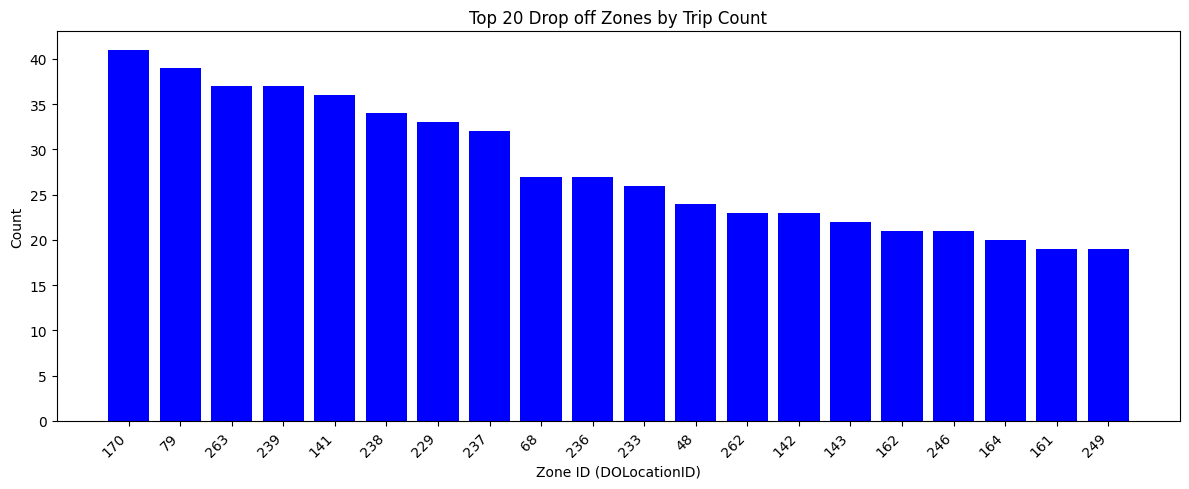

In [21]:
zone_counts = (df["DOLocationID"].value_counts().sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(zone_counts.index.astype(str), zone_counts.values, color="blue")
ax.set_xlabel("Zone ID (DOLocationID)")
ax.set_ylabel("Count")
ax.set_title("Top 20 Drop off Zones by Trip Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

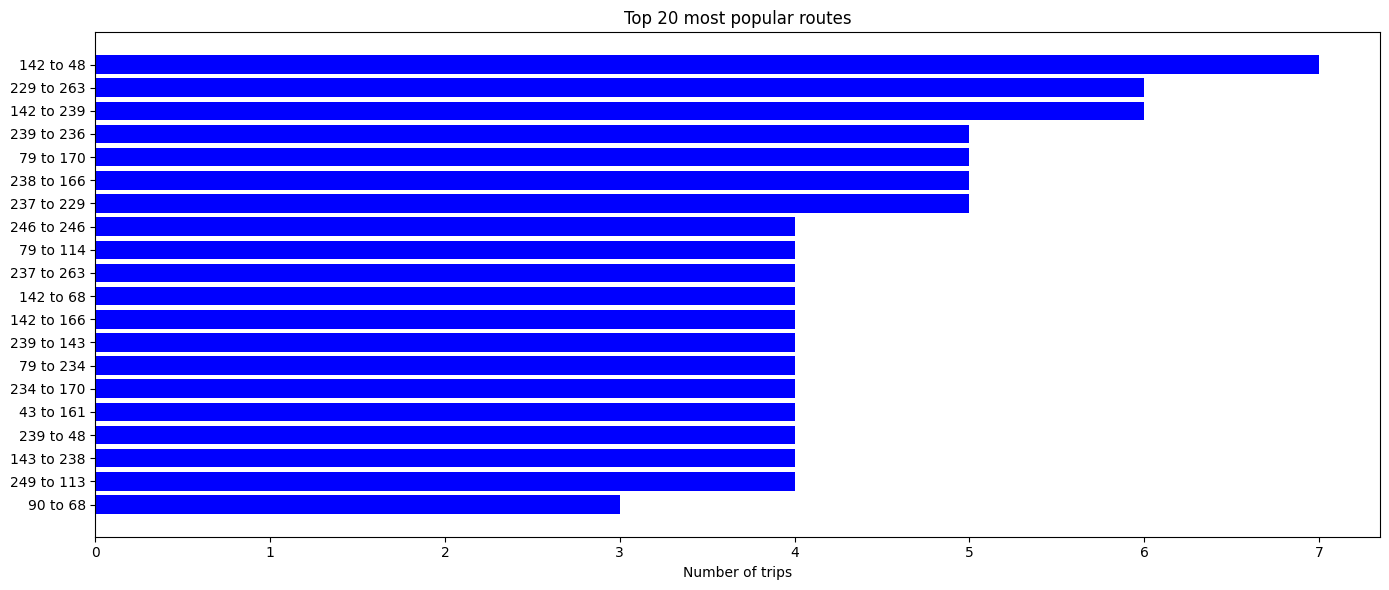

In [27]:
# Combine pickup + dropoff to one route
df['route'] = df['PULocationID'].astype(str) + ' to ' + df['DOLocationID'].astype(str)

route_counts = df['route'].value_counts().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(route_counts.index[::-1], route_counts.values[::-1], color='blue')
ax.set_xlabel('Number of trips')
ax.set_title('Top 20 most popular routes')
plt.tight_layout()
plt.show()
